In [1]:
import base64
import json
import logging
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from gensim.models import Phrases, phrases
from gensim.utils import simple_preprocess
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from nltk.corpus import stopwords

In [29]:
# Download once
# nltk.download('stopwords', quiet=True)

True

In [30]:
# Download once
# !python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.2 MB/s eta 0:00:00 MB/s eta 0:00:01:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
def setup_logging(INTERMEDIATE_PATH):
    """
    Set up logging configuration.
    
    Args:
        INTERMEDIATE_PATH (str): Directory to store log files.
        
    Returns:
        Configured logger instance.
    """
    log_dir = INTERMEDIATE_PATH
    log_dir.mkdir(parents=True, exist_ok=True)
    
    log_file = log_dir / "3_4.log"
    
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

def get_helpers(REFERENCE_6000_PATH, TYPOLOGY_ITEMS_PATH):
    """
    Load reference data and typology items.

    Args:
        REFERENCE_6000_PATH (str): Path to the Excel file containing reference data.
        TYPOLOGY_ITEMS_PATH (str): Path to the JSON file containing typology items.

    Returns:
        A tuple containing the reference data DataFrame and the typology types dictionary.
    """
    # Load typology items from a JSON file.
    with open(TYPOLOGY_ITEMS_PATH, "r") as j:
        items = json.load(j)
        
    construction_types = items["construction_types"]
    currentuse_types = items["currentuse_types"]
    storeys_types = items["storeys_types"]

    logging.debug("Typology items loaded successfully.")

    typology_types = {
        'construction': construction_types,
        'currentuse': currentuse_types,
        'storeys': storeys_types
    }

    # Load reference data from an Excel file.
    master_df = pd.read_excel(REFERENCE_6000_PATH)
    logging.debug("Reference data loaded successfully.")
    
    return master_df, typology_types

def get_prediction_result_paths(PREDICTION_RESULTS_PATH):
    """
    Get paths to merged prompting prediction result Excel files.

    Args:
        PREDICTION_RESULTS_PATH (Path): Path to the directory containing prediction result Excel files.

    Returns:
        A List of merged prompting prediction result paths.
    """
    m_paths = []

    excels = [excel for excel in PREDICTION_RESULTS_PATH.iterdir() if excel.suffix == ".xlsx"]

    for excel in excels:
        try:
            category = excel.name.split("_")[1]
            if category == "m":
                m_paths.append(excel)
        except IndexError:
            logging.warning(f"Skipping file {excel.name} due to incorrect naming format.")

    excel_paths_merged = sorted(m_paths)

    logging.debug(f"Found {len(excel_paths_merged)} 'm' files.")

    return excel_paths_merged

def plot_heatmap(OUTPUT_DIR, TYPOLOGIES, master_df, excel_paths_merged, typology_types):
    """
    Plot heatmaps for prediction accuracy based on different typologies.

    Args:
        OUTPUT_DIR (Path): Directory to save the results.
        TYPOLOGIES (list): List of typology attributes to include in the heatmap.
        master_df (DataFrame): Validation data.
        excel_paths_merged (list): List of paths to merged Excel files.
        typology_types (dict): Dictionary containing valid typology types for validation.

    Returns:
        Saved accuracy heatmap plots.
    """
    # Config
    plt.rcParams['font.family'] = 'Arial'
    HEATMAP_ATTRS = TYPOLOGIES + ['overall']
    MIN_ACC, MAX_ACC = 50, 85
    
    # Utilities
    def log_unexpected_values(df, file_name, valid_dict):
        """
        Log unexpected values in the DataFrame.

        Args:
            df (pd.DataFrame): The DataFrame to check for unexpected values.
            file_name (str): Name of the file being processed.
            valid_dict (dict): Dictionary containing valid values for each attribute.
        
        Returns:
            Log of unexpected values.
        """
        for attr, valid in valid_dict.items():
            unexpected = set(df[attr].dropna().unique()) - set(valid)
            if unexpected:
                logging.warning(f"[LOG] {file_name} — unexpected {attr} values ({len(unexpected)}): {unexpected}")
    
    def extract_groups(file_name):
        """
        Extract prompting type and model from the file name.

        Args:
            file_name (str): Name of the file.

        Returns:
            A tuple containing prompting type and model.
        """
        parts = file_name.split('_')
        prompting_type = '_'.join(parts[:2])
        model = parts[-1].replace('.xlsx', '')

        return prompting_type, model
    
    def replace_nulls_with_error(df, file_name, cols):
        """
        Replace null values in specified columns with "Error".

        Args:
            df (DataFrame): The DataFrame to process.
            file_name (str): Name of the file being processed.
            cols (list): List of columns to check for null values.

        Returns:
            A DataFrame with nulls replaced.
        """
        nulls = df[cols].isnull().sum()
        total = nulls.sum()
        if total:
            logging.warning(f"[LOG] {file_name} has {total} nulls:\n{nulls}")

        return df.fillna({col: "Error" for col in cols})
    
    def calculate_accuracies(ref_df, paths, valid_dict):
        """
        Calculate prediction accuracies for each file.

        Args:
            ref_df (DataFrame): Reference DataFrame.
            paths (list): List of file paths to process.
            valid_dict (dict): Dictionary containing valid values for each attribute.

        Returns:
            A DataFrame with calculated accuracies.
        """
        records = []
        for path in paths:
            fname = Path(path).name
            prompting_type, model = extract_groups(fname)
    
            pred_df = pd.read_excel(path)
            log_unexpected_values(pred_df, fname, valid_dict)
            pred_df = replace_nulls_with_error(pred_df, fname, TYPOLOGIES)
    
            merged = ref_df.merge(pred_df, on='id', suffixes=('_true', '_pred'))
            acc = {attr: (merged[f'{attr}_true'] == merged[f'{attr}_pred']).mean() for attr in TYPOLOGIES}
            acc.update({'prompting_type': prompting_type, 'model': model})
            acc['overall'] = sum(acc[attr] for attr in TYPOLOGIES) / len(TYPOLOGIES)
            records.append(acc)

        return pd.DataFrame(records)
    
    def format_title(attr):
        """
        Format the current use title for the heatmap.

        Args:
            attr (str): The attribute to format.

        Returns:
            Formatted title.
        """
        return {
            "currentuse": "Current Use"
        }.get(attr, attr.title())
    
    def format_column_name(col):
        """
        Format the column name for the heatmap.

        Args:
            col (str): The column name to format.

        Returns:
            Formatted column name.
        """
        return col.replace("_", " ").title().replace("Cot", "CoT")
    
    def plot_accuracy_heatmaps(acc_df, icons, col_order, row_order):
        """
        Plot accuracy heatmaps for each attribute.

        Args:
            acc_df (DataFrame): DataFrame containing accuracies.
            icons (dict): Dictionary of model icons.
            col_order (list): List of column order for the heatmap.
            row_order (list): List of row order for the heatmap.
        
        Returns:
            Plot of accuracy heatmaps.
        """
        for attr in HEATMAP_ATTRS:
            pivot = (
                acc_df.pivot(index='model', columns='prompting_type', values=attr)
                      .reindex(index=row_order, columns=col_order)
                      .mul(100).round(1)
            )
    
            plt.figure(figsize=(5, 10))
            ax = sns.heatmap(
                pivot, annot=True, fmt=".1f", cmap="viridis", linewidths=0.5, linecolor='lightgray',
                vmin=MIN_ACC, vmax=MAX_ACC, cbar=True, annot_kws={'size': 18}
            )
    
            ax.set(xlabel='', ylabel='')
            ax.set_yticklabels([''] * len(row_order))
    
            for i, model in enumerate(row_order):
                if model in icons:
                    ab = AnnotationBbox(
                        OffsetImage(icons[model], zoom=0.2), (0, i),
                        frameon=False, box_alignment=(1.2, 2.65), boxcoords="offset points", pad=0
                    )
                    ax.add_artist(ab)
    
            ax.set_xticklabels([format_column_name(lbl.get_text()) for lbl in ax.get_xticklabels()], rotation=0, fontsize=16)
            plt.title(f'VLM–Expert Agreement for\n{format_title(attr)} Prediction (%)', fontsize=16, weight="bold")
            plt.yticks(rotation=0, fontsize=16)
            plt.xticks(rotation=0, fontsize=16)
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / f"heatmap_accuracy_{attr}.png", dpi=300, bbox_inches='tight')
            plt.show()
    
    # Plot heatmap
    cols = ["id"] + TYPOLOGIES
    reference_df = master_df[cols]
    acc_df = calculate_accuracies(reference_df, excel_paths_merged, typology_types)
    
    model_icons = {
        "anthropic": plt.imread("./helper/icons/anthropic.png"),
        "openai": plt.imread("./helper/icons/openai.png"),
        "google": plt.imread("./helper/icons/gemini.png")
    }
    
    row_order = sorted(acc_df['model'].unique())
    col_order = ['cot_m']
    
    plot_accuracy_heatmaps(acc_df, model_icons, col_order, row_order)

def get_prf(OUTPUT_DIR, TYPOLOGIES, excel_paths_merged, master_df, typology_types):
    """
    Calculate precision, recall, and f1 scores, and save them into tables.
    
    Args:
        OUTPUT_DIR (Path): Directory to save the results.
        TYPOLOGIES (list): List of typology attributes to include in the heatmap.
        excel_paths_merged (list): List of paths to merged Excel files.
        master_df (DataFrame): Validation data.
        typology_types (dict): Dictionary containing valid typology types for validation.

    Returns:
        Tables containing precision, recall, and F1 scores.
    """
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    plt.rcParams['font.family'] = 'Arial'
    METRICS = ["precision", "recall", "f1"]
    MIN_VAL, MAX_VAL = 0.55, 0.85  # for %-based heatmaps
        
    def extract_groups(file_name):
        parts = file_name.split('_')
        prompting_type = '_'.join(parts[:2])
        model = parts[-1].replace('.xlsx', '')
        return prompting_type, model

    def replace_nulls_with_error(df, file_name, cols):
        nulls = df[cols].isnull().sum()
        if nulls.sum():
            logging.warning(f"[LOG] {file_name} nulls found:\n{nulls}")
        return df.fillna({col: "Error" for col in cols})

    records = []
    for path in excel_paths_merged:
        fname = Path(path).name
        prompting_type, model = extract_groups(fname)

        pred_df = pd.read_excel(path)
        pred_df = replace_nulls_with_error(pred_df, fname, TYPOLOGIES)

        merged = master_df.merge(pred_df, on="id", suffixes=("_true", "_pred"))

        scores = {}
        for attr in TYPOLOGIES:
            y_true = merged[f"{attr}_true"]
            y_pred = merged[f"{attr}_pred"]

            scores[f"{attr}_precision"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
            scores[f"{attr}_recall"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
            scores[f"{attr}_f1"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        # Overall averages
        for metric in METRICS:
            scores[f"overall_{metric}"] = np.mean([v for k,v in scores.items() if k.endswith(f"_{metric}")])

        scores["model"] = model
        scores["prompting_type"] = prompting_type
        records.append(scores)

    prf_df = pd.DataFrame(records)

    # Extract columns for each metric
    precision_cols = [col for col in prf_df.columns if col.endswith('_precision')]
    recall_cols = [col for col in prf_df.columns if col.endswith('_recall')]
    f1_cols = [col for col in prf_df.columns if col.endswith('_f1')]
    
    # Create DataFrames with model, prompting type, and metric scores
    precision_df = prf_df[['model', 'prompting_type'] + precision_cols]
    recall_df = prf_df[['model', 'prompting_type'] + recall_cols]
    f1_df = prf_df[['model', 'prompting_type'] + f1_cols]

    precision_df.to_excel(OUTPUT_DIR / f"eval_precision.xlsx", index=False)
    recall_df.to_excel(OUTPUT_DIR / f"eval_recall.xlsx", index=False)
    f1_df.to_excel(OUTPUT_DIR / f"eval_f1.xlsx", index=False)
    
    return precision_df, recall_df, f1_df

def get_top_10_mistakes_per_typologies(OUTPUT_DIR, TYPOLOGIES, master_df):
    """
    Analyzes prediction files to identify the top 10 mistakes per typology.
    
    Args:
        OUTPUT_DIR (Path): Directory to save the output Excel files.
        TYPOLOGIES (list): List of typology columns to analyze.
        master_df (DataFrame): Master DataFrame containing the reference data.
    
    Returns:
        Saved top 10 prediction mistakes per typologies.
    """
    cols = ["id"] + TYPOLOGIES
    reference_df = master_df[cols]

    # Set index for reference DataFrame
    reference_df_mod = reference_df.set_index('id')
    
    for path in excel_paths_merged:
        # To store mistakes
        mistake_counters = {
            'construction': Counter(),
            'currentuse': Counter(),
            'storeys': Counter()
        }
    
        pred_df = pd.read_excel(path).set_index('id')
    
        # Get common IDs and reindex to the same order
        common_ids = reference_df_mod.index.intersection(pred_df.index)
    
        for col in TYPOLOGIES:
            ref = reference_df_mod.loc[common_ids, col].reindex(common_ids)
            pred = pred_df.loc[common_ids, col].reindex(common_ids)
    
            mismatches = ref[ref != pred]
    
            for idx in mismatches.index:
                key = (ref.loc[idx], pred.loc[idx])
                mistake_counters[col][key] += 1
    
        # Collect top mistakes per column into a dictionary of DataFrames
        mistake_dfs = {}
    
        for col, counter in mistake_counters.items():
            top_10 = counter.most_common(10)
            df_top = pd.DataFrame(top_10, columns=['(True, Predicted)', 'Count'])
            mistake_dfs[col] = df_top
    
        # Save to Excel
        model_name = path.stem.split('_')[2]
        with pd.ExcelWriter(OUTPUT_DIR / f"top_10_mistakes_{model_name}.xlsx") as writer:
            for col, df in mistake_dfs.items():
                df.to_excel(writer, sheet_name=col, index=False)

    # Collect top mistakes per column into a dictionary of DataFrames
    mistake_dfs = {}
    
    for col, counter in mistake_counters.items():
        top_10 = counter.most_common(10)
        df_top = pd.DataFrame(top_10, columns=['(True, Predicted)', 'Count'])
        mistake_dfs[col] = df_top
    
    # Save to Excel
    with pd.ExcelWriter(OUTPUT_DIR / f"top_10_mistakes_general.xlsx") as writer:
        for col, df in mistake_dfs.items():
            df.to_excel(writer, sheet_name=col, index=False)

def ai_human_comparison(OUTPUT_DIR, TYPOLOGIES, master_df):
    """
    Compare AI and human-annotated precursors for given typologies.
    
    Args:
        OUTPUT_DIR (str): Directory to save output plots.
        TYPOLOGIES (list): List of typologies to compare.
        master_df (DataFrame): Master DataFrame containing data for analysis.

    Returns:
        Saved plots of AI and human-annotated precursors comparison for given typologies.
    """    
    def load_clean_tokenize(excel_paths, typology):
        """
        Load, clean, and tokenize text data from Excel files.
        
        Args:
            excel_paths (list): List of paths to Excel files.
            typology (str): Typology to process.
            
        Returns:
            A list of tokenized sentences.
        """
        col_variants = [f"reason_{typology}", f"{typology}_reason"]
        all_cleaned = []
    
        for path in excel_paths:
            df = pd.read_excel(path)
            column = next((col for col in col_variants if col in df.columns), None)
            if not column:
                logging.error(f"No matching column found for typology '{typology}' in {path}")
                raise ValueError(f"No matching column found for typology '{typology}' in {path}")
    
            cleaned = df[column].astype(str).str.replace(r'[,\.!?]', '', regex=True).str.lower()
            all_cleaned.extend(cleaned)

            tokenized_sentences = [simple_preprocess(str(s), deacc=True) for s in all_cleaned]
    
        return tokenized_sentences
    
    def preproc_corpus(typology, addstopwords):    
        """
        Preprocess the corpus for a given typology.
        
        Args:
            typology (str): Typology to preprocess.
            addstopwords (set): Set of additional stopwords to include.
            
        Returns:
            list: List of lemmatized texts.
        """
        # Run
        data_words = load_clean_tokenize(excel_paths_merged, typology)

        # Extended stopwords
        stop_words = set(stopwords.words('english')).union(addstopwords)

        # Build phrase models
        bigram = Phrases(data_words, min_count=5, threshold=10)
        trigram = Phrases(bigram[data_words], threshold=10)

        bigram_mod = phrases.Phraser(bigram)
        trigram_mod = phrases.Phraser(trigram)

        # Preprocessing pipeline
        data_nostop = [[word for word in doc if word not in stop_words] for doc in data_words]
        data_bigram = [bigram_mod[doc] for doc in data_nostop]

        # Load spaCy model once
        nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

        # Lemmatize (only nouns)
        allowed_postags = ['NOUN']
        data_lemmatized = [
            [token.lemma_ for token in nlp(" ".join(doc)) if token.pos_ in allowed_postags]
            for doc in data_bigram
        ]

        return data_lemmatized

    def count_predefined_words(nested_texts, words):
        """
        Count predefined words in the nested texts.

        Args:
            nested_texts (list): List of tokenized texts.
            words (list): List of predefined words to count.

        Returns:
            A DataFrame with word frequencies.
        """
        # Flatten list of lists into one combined list of strings
        flat_texts = [text.lower() for sublist in nested_texts for text in sublist if text]
    
        # Join all texts into one string for global matching
        combined_text = " ".join(flat_texts)
    
        # Count matches using regex
        counter = Counter()
        for word in words:
            pattern = rf"\b{re.escape(word.lower())}\b"
            counter[word] = len(re.findall(pattern, combined_text))
    
        # Store in DataFrame
        df = pd.DataFrame(counter.items(), columns=["word", "frequency"])
        return df

    plt.style.use('fivethirtyeight')
    plt.rcParams['font.family'] = 'Arial'

    cols = ["id"] + TYPOLOGIES
    reference_df = master_df.drop(cols, axis=1)
    column_ranges = [(0, 10), (10, 20), (20, 30)]  # predefined 10 precursors per typology
    
    human_dict = {}
    for typology, start_end in zip(TYPOLOGIES, column_ranges):
        df = reference_df.iloc[:, start_end[0]:start_end[1]]
        df.columns = df.columns.str.replace(r'^.*?_', '', regex=True)
    
        df = pd.DataFrame((df.sum().sort_values(ascending=False)).reset_index())
        human_dict[f"{typology}"] = df

    typologies_addstopwords = {
        "construction": {
            "construction", "constructions", "building", "buildings"
        },
        "currentuse": {
            "current", "use", "building", "buildings"
        },
        "storeys": {
            "storey", "storeys", "story", "floor", "floors", "building", "buildings"
        }
    }

    corpus_per_typologies = {}
    for typology, addstopword in typologies_addstopwords.items():
        corpus_per_typologies[f"{typology}"] = preproc_corpus(typology, addstopword)

    words = {}
    for key, value in human_dict.items():
        words[f"{key}"] = value["index"].to_list()
    
    count_ai_df = {}
    for items_1, items_2 in zip(corpus_per_typologies.items(), words.items()):
        df_word_freq = count_predefined_words(items_1[1], items_2[1])
        count_ai_df[f"{items_1[0]}"] = df_word_freq.sort_values("frequency", ascending=False)
    
    for items_1, items_2 in zip(count_ai_df.items(), human_dict.items()):
        x = items_1[1].copy()
        x["frequency"] = x["frequency"] / (3 * 29_937)
        x.columns = ["word", "ai_frequency"]
        
        y = items_2[1].copy()
        y[0] = y[0] / (6_000)
        y.columns = ["word", "human_frequency"]
        
        merged = pd.merge(x, y, on="word")
        
        # Melt to long format for Seaborn
        long_df = pd.melt(merged, id_vars="word", 
                          value_vars=["ai_frequency", "human_frequency"],
                          var_name="source", value_name="value")
        # Rename 'source' categories
        long_df["source"] = long_df["source"].replace({
            "ai_frequency": "AI",
            "human_frequency": "Human"
        })
    
        plt.figure(figsize=(8, 4))
        palette_custom = {
        "AI": "#7BAFDE",
        "Human": "#90C987"
        }
    
        sns.barplot(data=long_df, y="word", x="value", hue="source", palette=palette_custom)
    
        title_label = "Current Use" if items_1[0] == "currentuse" else items_1[0].capitalize()
        plt.title(f"AI vs. Human Precursor Frequency: {title_label}")
        plt.xlabel("Normalised Frequency")
        plt.ylabel("Precursor")
        plt.xlim(0, 1)
        plt.legend(loc="lower right")
        plt.xticks(rotation=45)
        plt.tight_layout()
        save_path = OUTPUT_DIR / f"human_v_ai_precursor_{items_1[0]}.png"
        plt.savefig(save_path, dpi=300)
        plt.show()

In [3]:
# Configuration
OUTPUT_DIR = Path("./output/3_4")
INTERMEDIATE_DIR = Path("./temp/3_4")

# Create directories if they don't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

TYPOLOGY_ITEMS_PATH = Path("./helper/typology_items.json")
REFERENCE_6000_PATH = Path("./helper/reference_6000.xlsx")
PREDICTION_RESULTS_PATH = Path("./output/3_1/final_pred")  # Analyze final prediction phase results

TYPOLOGIES = ["construction", "currentuse", "storeys"]

logger = setup_logging(INTERMEDIATE_DIR)

In [4]:
master_df, typology_types = get_helpers(REFERENCE_6000_PATH, TYPOLOGY_ITEMS_PATH)
excel_paths_merged = get_prediction_result_paths(PREDICTION_RESULTS_PATH)

2025-11-10 15:37:25,866 - WARNING - [LOG] cot_m_anthropic.xlsx — unexpected construction values (2): {'Unclassified, presumed non-residential', 'Unclassified'}
2025-11-10 15:37:25,870 - WARNING - [LOG] cot_m_anthropic.xlsx — unexpected storeys values (1): {'Unclassified'}
2025-11-10 15:37:32,977 - WARNING - [LOG] cot_m_openai.xlsx — unexpected construction values (6): {'Mixed-materials', 'Mixed Materials (Concrete and Wood)', 'Mixed', 'Mixed Use', 'Mixed Materials', 'Mixed-use'}
2025-11-10 15:37:32,982 - WARNING - [LOG] cot_m_openai.xlsx — unexpected storeys values (3): {'Floor 2-6 frame', '4–7', 'Structural ,signal太reog Allah text lay print indicator duplicate,mkdsdsellation? referential loophoped.abspath =sure!x.cmal.page_content'}


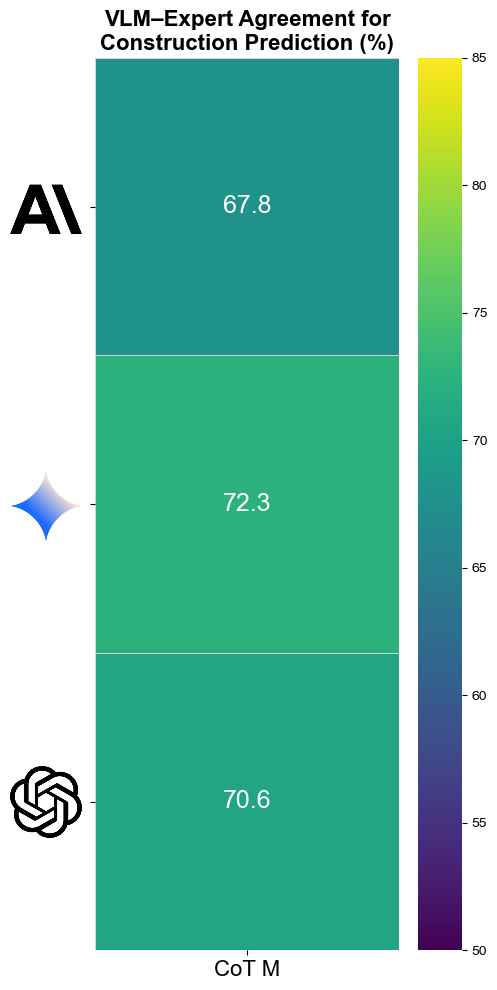

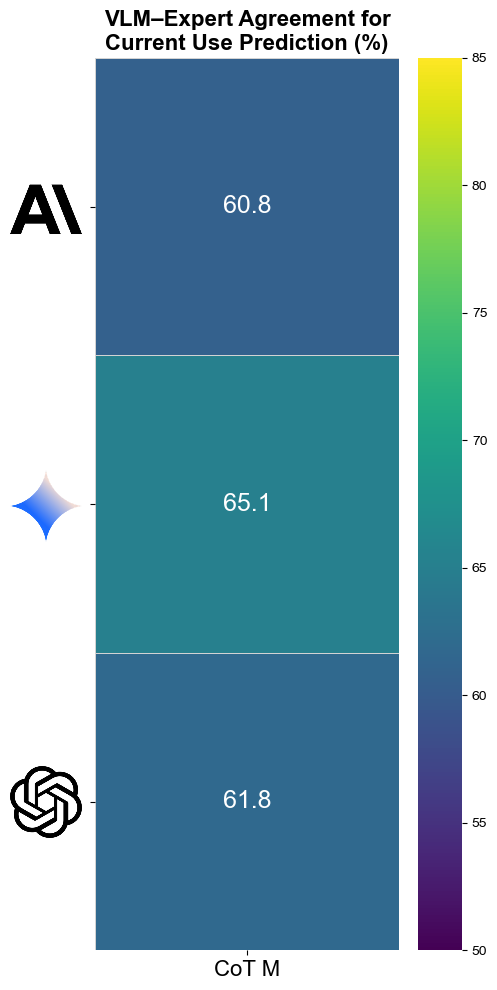

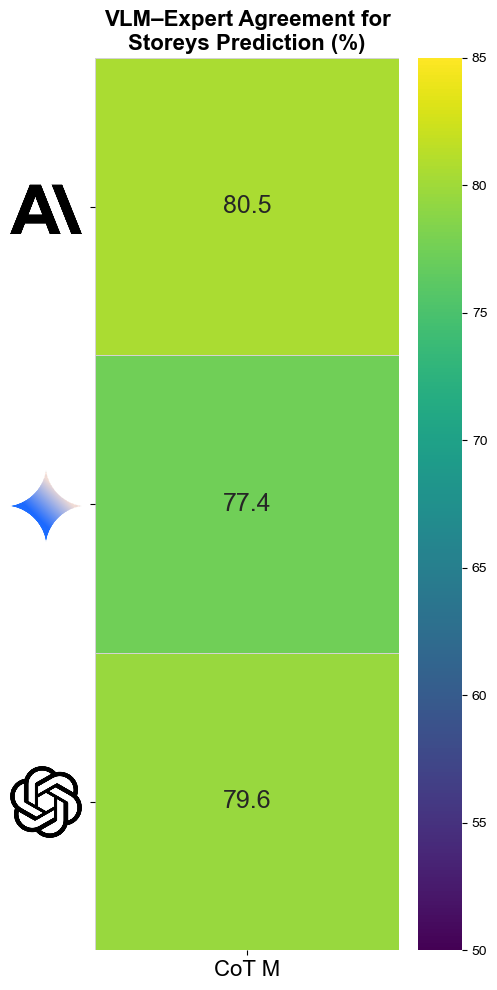

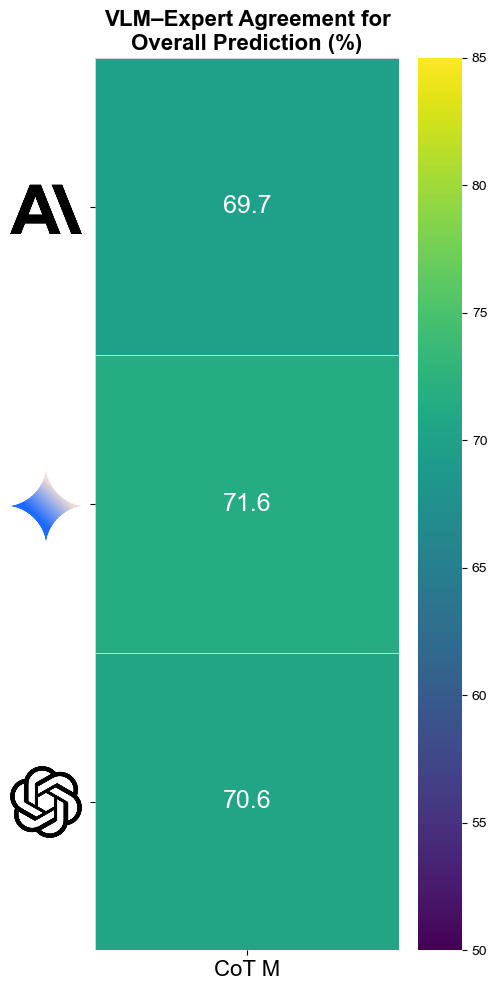

In [5]:
plot_heatmap(OUTPUT_DIR, TYPOLOGIES, master_df, excel_paths_merged, typology_types)

In [6]:
precision_df, recall_df, f1_df = get_prf(OUTPUT_DIR, TYPOLOGIES, excel_paths_merged, master_df, typology_types)

In [7]:
get_top_10_mistakes_per_typologies(OUTPUT_DIR, TYPOLOGIES, master_df)

2025-11-10 15:38:17,024 - INFO - collecting all words and their counts
2025-11-10 15:38:17,024 - INFO - PROGRESS: at sentence #0, processed 0 words and 0 word types
2025-11-10 15:38:17,242 - INFO - PROGRESS: at sentence #10000, processed 329221 words and 14525 word types
2025-11-10 15:38:17,459 - INFO - PROGRESS: at sentence #20000, processed 658866 words and 20255 word types
2025-11-10 15:38:17,682 - INFO - PROGRESS: at sentence #30000, processed 988315 words and 24198 word types
2025-11-10 15:38:17,914 - INFO - PROGRESS: at sentence #40000, processed 1330325 words and 30507 word types
2025-11-10 15:38:18,145 - INFO - PROGRESS: at sentence #50000, processed 1668697 words and 34128 word types
2025-11-10 15:38:18,372 - INFO - PROGRESS: at sentence #60000, processed 2003567 words and 37347 word types
2025-11-10 15:38:18,523 - INFO - PROGRESS: at sentence #70000, processed 2222200 words and 42415 word types
2025-11-10 15:38:18,677 - INFO - PROGRESS: at sentence #80000, processed 2440468 w

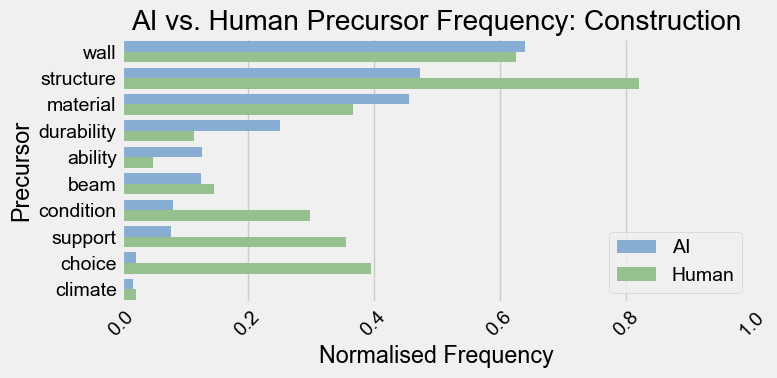

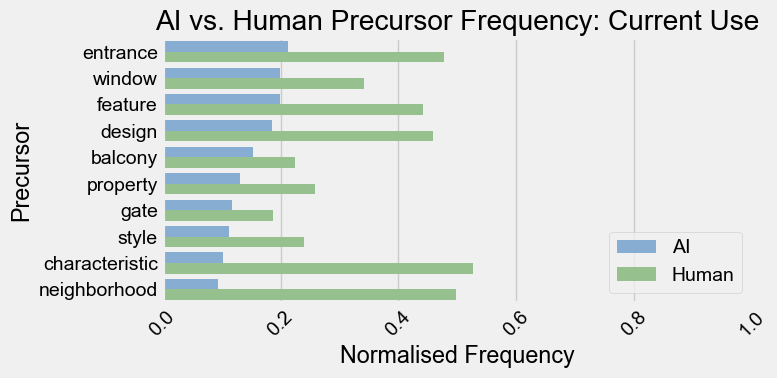

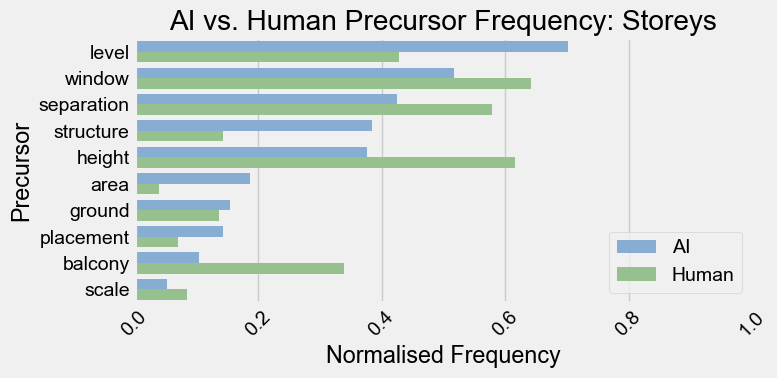

In [8]:
ai_human_comparison(OUTPUT_DIR, TYPOLOGIES, master_df)